## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_2023-June-1st_filled.csv', encoding=enc)
#wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Timeline_2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2023-06-01,2023,6,2023-05-30,37.991999,23.654887,0.081425,-0.017010,-0.130960,0.017010,0.121710,-0.009491,-0.158340,0.009491,0.029462,0.007071,0.018681,0.007071,2023-05-29,37.991999,23.654887,15442.0,14645.0,37.991999,23.654887,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,2023-04-09,37.950174,23.650108,318.222359,2023-05-25,2023-05-18,2023-04-09,2023-04-09,0.0,0.0
1,αγιας παρασκευης,αττικης,23.82642,38.00806,2023-06-01,2023,6,2023-05-30,38.009965,23.825567,0.182029,0.039896,-0.202575,-0.039896,0.179347,0.052340,-0.193288,-0.052340,0.029700,0.018066,0.026029,0.018066,2023-05-29,38.009965,23.825567,15065.0,NaN,38.009965,23.825567,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,2023-04-09,38.050174,23.850109,389.356250,2023-05-25,2023-05-18,2023-04-09,2023-04-09,0.0,0.0
2,αγιου δημητριου,αττικης,23.73031,37.93357,2023-06-01,2023,6,2023-05-30,37.933609,23.731244,0.129539,-0.004290,-0.181516,0.004290,0.109737,-0.010156,-0.161746,0.010156,0.019872,0.008452,0.017236,0.008452,2023-05-29,37.933609,23.731244,15386.0,14644.0,37.933609,23.731244,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,2023-04-09,37.950174,23.750109,355.883585,2023-05-25,2023-05-18,2023-04-09,2023-04-09,0.0,0.0
3,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2023-06-01,2023,6,2023-05-30,38.045898,23.713278,0.138934,-0.021343,-0.182142,0.021343,0.160739,-0.030744,-0.199161,0.030744,0.028147,0.011592,0.019271,0.011592,2023-05-29,38.045898,23.713278,15423.0,14607.0,38.045898,23.713278,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,2023-04-09,38.050174,23.750109,397.347602,2023-05-25,2023-05-18,2023-04-09,2023-04-09,0.0,0.0
4,αγκιστριου,αττικης,23.34009,37.69503,2023-06-01,2023,6,2023-05-30,37.695555,23.340477,0.322945,-0.016507,-0.251751,0.016507,0.312206,0.021206,-0.233773,-0.021206,0.070354,0.053917,0.070853,0.053917,2023-05-29,37.695555,23.340477,14788.0,14626.0,37.695555,23.340477,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,2023-04-09,37.650172,23.350107,472.697967,2023-05-25,2023-05-18,2023-04-09,2023-04-09,0.0,0.0


In [6]:
#wnv_file.head()

In [7]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
timeline_file = timeline_file.rename(columns=lambda x: re.sub('_new', '', x))

In [9]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [10]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2023-06-01,2023,6,0.081425,-0.017010,-0.130960,0.017010,0.121710,-0.009491,-0.158340,0.009491,0.029462,0.007071,0.018681,0.007071,15442.0,14645.0,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,318.222359,0.0,0.0
1,αγιας παρασκευης,αττικης,23.82642,38.00806,2023-06-01,2023,6,0.182029,0.039896,-0.202575,-0.039896,0.179347,0.052340,-0.193288,-0.052340,0.029700,0.018066,0.026029,0.018066,15065.0,NaN,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,389.356250,0.0,0.0
2,αγιου δημητριου,αττικης,23.73031,37.93357,2023-06-01,2023,6,0.129539,-0.004290,-0.181516,0.004290,0.109737,-0.010156,-0.161746,0.010156,0.019872,0.008452,0.017236,0.008452,15386.0,14644.0,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,355.883585,0.0,0.0
3,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2023-06-01,2023,6,0.138934,-0.021343,-0.182142,0.021343,0.160739,-0.030744,-0.199161,0.030744,0.028147,0.011592,0.019271,0.011592,15423.0,14607.0,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,397.347602,0.0,0.0
4,αγκιστριου,αττικης,23.34009,37.69503,2023-06-01,2023,6,0.322945,-0.016507,-0.251751,0.016507,0.312206,0.021206,-0.233773,-0.021206,0.070354,0.053917,0.070853,0.053917,14788.0,14626.0,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,472.697967,0.0,0.0


In [11]:
#wnv_file.head(5)

In [12]:
# ## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")


In [13]:
#wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))

In [14]:
# ## Check again

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [15]:
# merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )
merged = timeline_file

In [16]:
# merged

In [17]:
# merged = fillna(merged,{'case': 0})
merged['case'] = 0

In [18]:
merged['case'].value_counts()

0    152
Name: case, dtype: int64

In [19]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [20]:
dataset = grouped.mean()

In [21]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2023-06-01,αγιας βαρβαρας,αττικης,23.656970,37.992200,2023.0,6.0,0.081425,-0.017010,-0.130960,0.017010,0.121710,-0.009491,-0.158340,0.009491,0.029462,0.007071,0.018681,0.007071,15442.000000,14645.000000,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,318.222359,0.0,0.0,0.0
1,2023-06-01,αγιας παρασκευης,αττικης,23.826420,38.008060,2023.0,6.0,0.182029,0.039896,-0.202575,-0.039896,0.179347,0.052340,-0.193288,-0.052340,0.029700,0.018066,0.026029,0.018066,15065.000000,NaN,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,389.356250,0.0,0.0,0.0
2,2023-06-01,αγιου δημητριου,αττικης,23.730310,37.933570,2023.0,6.0,0.129539,-0.004290,-0.181516,0.004290,0.109737,-0.010156,-0.161746,0.010156,0.019872,0.008452,0.017236,0.008452,15386.000000,14644.000000,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,355.883585,0.0,0.0,0.0
3,2023-06-01,αγιων αναργυρων καματερου,αττικης,23.713410,38.047210,2023.0,6.0,0.138934,-0.021343,-0.182142,0.021343,0.160739,-0.030744,-0.199161,0.030744,0.028147,0.011592,0.019271,0.011592,15423.000000,14607.000000,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,397.347602,0.0,0.0,0.0
4,2023-06-01,αγκιστριου,αττικης,23.340090,37.695030,2023.0,6.0,0.322945,-0.016507,-0.251751,0.016507,0.312206,0.021206,-0.233773,-0.021206,0.070354,0.053917,0.070853,0.053917,14788.000000,14626.000000,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,472.697967,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2023-06-01,φιλοθεης ψυχικου,αττικης,23.776280,38.014770,2023.0,6.0,0.181323,0.085061,-0.170092,-0.085061,0.087042,0.072896,-0.070668,-0.072896,0.009643,0.014180,0.005796,0.014180,15228.000000,14598.000000,14336.631579,14058.052632,14351.083333,13962.608696,14601.846154,14136.722222,14814.133333,14253.928571,397.347602,0.0,0.0,0.0
62,2023-06-01,φυλης,αττικης,23.688620,38.106703,2023.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15167.333333,14430.333333,14286.856209,13919.959831,14262.083333,13867.802315,14500.012698,14007.878571,14697.305556,14082.353535,365.355446,0.0,0.0,0.0
63,2023-06-01,χαλανδριου,αττικης,23.809410,38.022260,2023.0,6.0,NaN,NaN,NaN,NaN,0.184956,0.046558,-0.206145,-0.046558,0.009028,0.006444,0.010324,0.006444,15278.000000,14516.000000,14348.000000,14057.578947,14377.500000,13986.142857,14647.666667,14128.588235,14793.333333,14171.142857,389.356250,0.0,0.0,0.0
64,2023-06-01,χαϊδαριου,αττικης,23.630840,38.009420,2023.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15396.000000,14645.000000,14355.380952,14021.611111,14362.533333,13924.600000,14569.875000,14147.933333,14794.058824,14248.400000,407.034266,0.0,0.0,0.0


In [22]:
dataset = dataset.astype({'case': 'int'})

In [23]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [24]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [25]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [26]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [27]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2023-06-01,αγιας βαρβαρας,αττικης,23.65697,37.99220,2023,6,0.081425,-0.017010,-0.130960,0.017010,0.121710,-0.009491,-0.158340,0.009491,0.029462,0.007071,0.018681,0.007071,15442.000000,14645.000000,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,318.222359,0.0,0.0,0,1,22,44.75555,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
1,2023-06-01,αγιας παρασκευης,αττικης,23.82642,38.00806,2023,6,0.182029,0.039896,-0.202575,-0.039896,0.179347,0.052340,-0.193288,-0.052340,0.029700,0.018066,0.026029,0.018066,15065.000000,NaN,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,389.356250,0.0,0.0,0,1,22,44.85879,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
2,2023-06-01,αγιου δημητριου,αττικης,23.73031,37.93357,2023,6,0.129539,-0.004290,-0.181516,0.004290,0.109737,-0.010156,-0.161746,0.010156,0.019872,0.008452,0.017236,0.008452,15386.000000,14644.000000,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,355.883585,0.0,0.0,0,1,22,44.74465,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
3,2023-06-01,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2023,6,0.138934,-0.021343,-0.182142,0.021343,0.160739,-0.030744,-0.199161,0.030744,0.028147,0.011592,0.019271,0.011592,15423.000000,14607.000000,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,397.347602,0.0,0.0,0,1,22,44.83209,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
4,2023-06-01,αγκιστριου,αττικης,23.34009,37.69503,2023,6,0.322945,-0.016507,-0.251751,0.016507,0.312206,0.021206,-0.233773,-0.021206,0.070354,0.053917,0.070853,0.053917,14788.000000,14626.000000,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,472.697967,0.0,0.0,0,1,22,44.33593,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2023-06-01,φιλοθεης ψυχικου,αττικης,23.77628,38.01477,2023,6,0.181323,0.085061,-0.170092,-0.085061,0.087042,0.072896,-0.070668,-0.072896,0.009643,0.014180,0.005796,0.014180,15228.000000,14598.000000,14336.631579,14058.052632,14351.083333,13962.608696,14601.846154,14136.722222,14814.133333,14253.928571,397.347602,0.0,0.0,0,1,22,44.83787,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
62,2023-06-01,φυλης,αττικης,23.68862,38.10670,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15167.333333,14430.333333,14286.856209,13919.959831,14262.083333,13867.802315,14500.012698,14007.878571,14697.305556,14082.353535,365.355446,0.0,0.0,0,1,22,44.86949,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
63,2023-06-01,χαλανδριου,αττικης,23.80941,38.02226,2023,6,NaN,NaN,NaN,NaN,0.184956,0.046558,-0.206145,-0.046558,0.009028,0.006444,0.010324,0.006444,15278.000000,14516.000000,14348.000000,14057.578947,14377.500000,13986.142857,14647.666667,14128.588235,14793.333333,14171.142857,389.356250,0.0,0.0,0,1,22,44.86179,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044
64,2023-06-01,χαϊδαριου,αττικης,23.63084,38.00942,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15396.000000,14645.000000,14355.380952,14021.611111,14362.533333,13924.600000,14569.875000,14147.933333,14794.058824,14248.400000,407.034266,0.0,0.0,0,1,22,44.75637,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044


<AxesSubplot:>

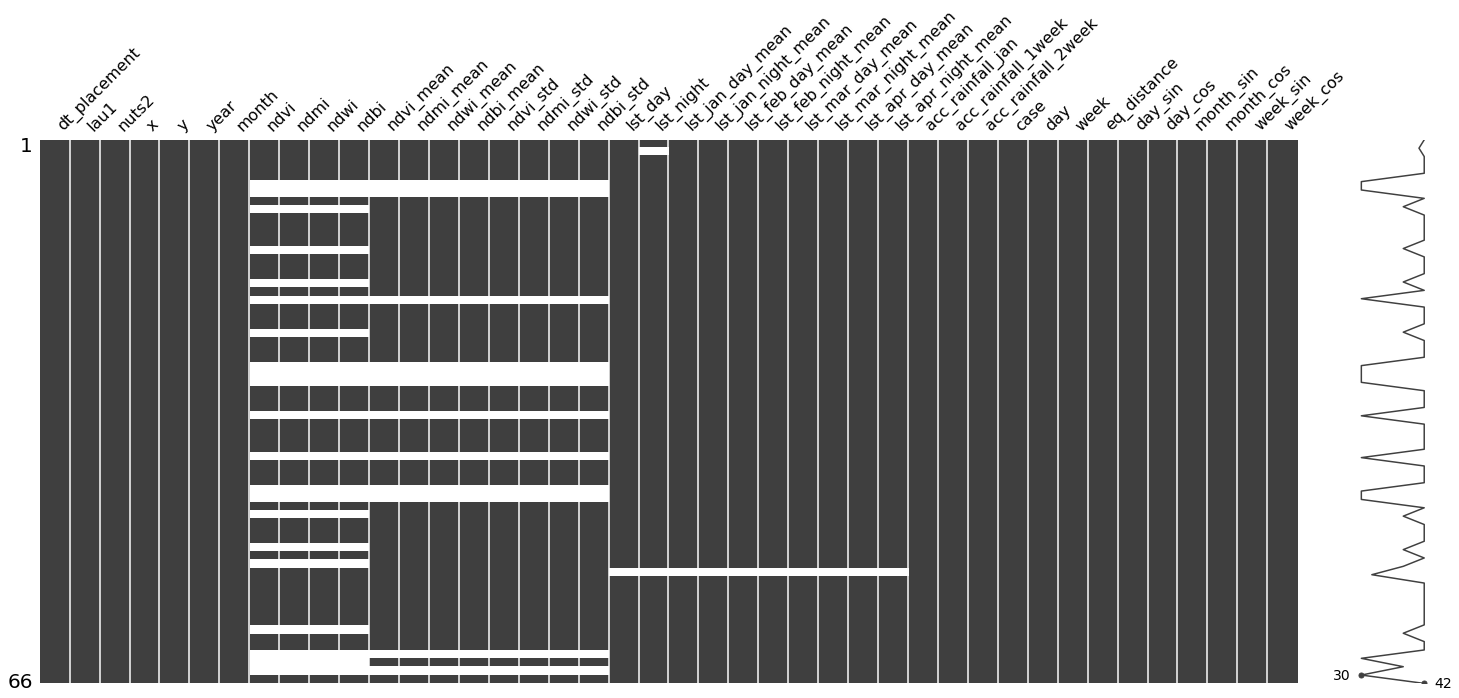

In [28]:
missingno.matrix(dataset)

In [29]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [30]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [31]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [32]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [33]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αγιας βαρβαρας,2.4,10925.9,26759.0
1,αγιας παρασκευης,7.9,7557.5,62157.0
2,αγιου δημητριου,5.0,14402.8,71747.0
3,αγιων αναργυρων καματερου,9.2,6833.8,61427.0
4,αγκιστριου,13.4,85.2,1107.0
...,...,...,...,...
61,φιλοθεης ψυχικου,6.1,4421.0,27400.0
62,φυλης,109.1,421.2,48255.0
63,χαϊδαριου,22.7,2069.6,46983.0
64,χαλανδριου,10.8,6869.6,77118.0


In [34]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['νικαιας αγιου ι. ρεντη', 'πειραιως', 'τροιζηνιας', 'φιλαδελφειας χαλκηδονος']

Length: 4


In [35]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('νικαιας αγιου ιωαννη ρεντη', 'νικαιας αγιου ι. ρεντη'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('πειραια', 'πειραιως',))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('τροιζηνιας μεθανων', 'τροιζηνιας'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('νεας φιλαδελφειας νεας χαλκηδονας','φιλαδελφειας χαλκηδονος'))


In [36]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [37]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

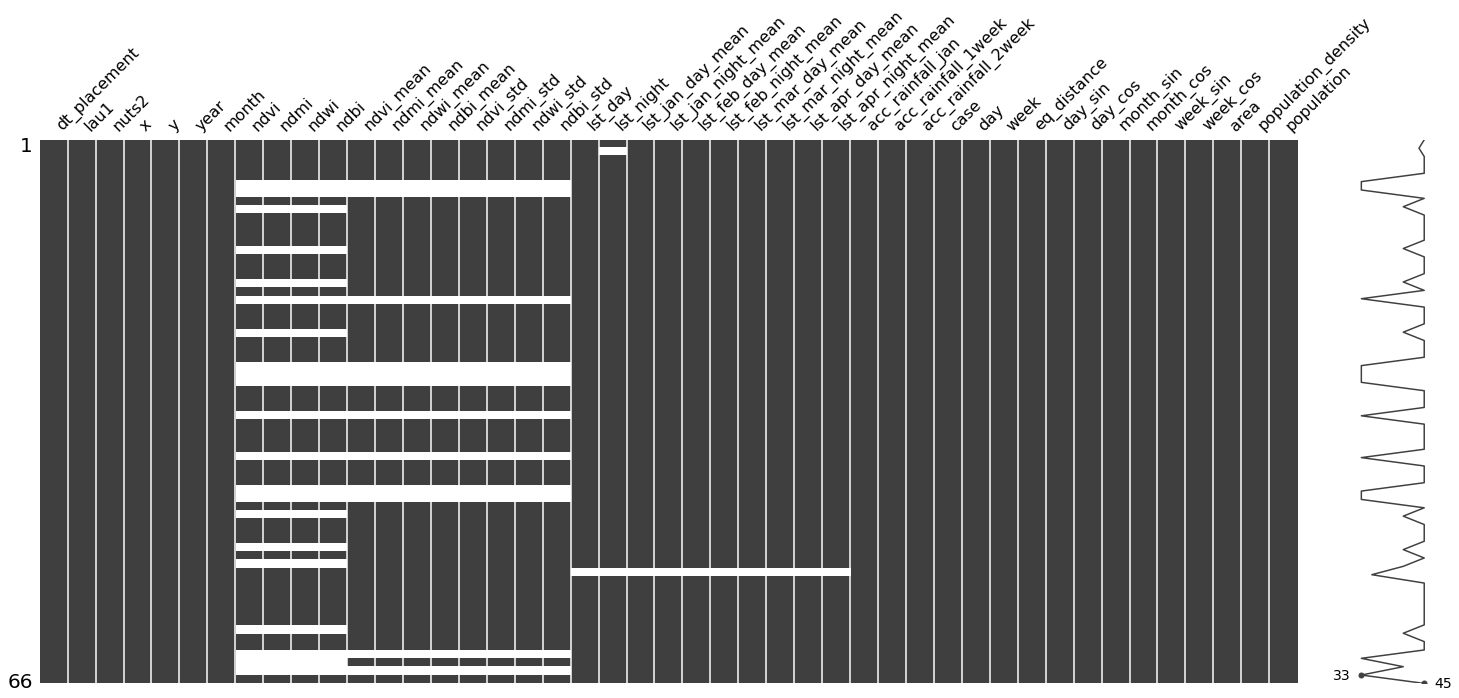

In [38]:
missingno.matrix(dataset)

In [39]:
missing = describe_dataframe(dataset)

In [40]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2023-06-01,αγιας βαρβαρας,αττικης,23.65697,37.99220,2023,6,0.081425,-0.017010,-0.130960,0.017010,0.121710,-0.009491,-0.158340,0.009491,0.029462,0.007071,0.018681,0.007071,15442.000000,14645.000000,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,318.222359,0.0,0.0,0,1,22,44.75555,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,2.4,10925.9,26759.0
1,2023-06-01,αγιας παρασκευης,αττικης,23.82642,38.00806,2023,6,0.182029,0.039896,-0.202575,-0.039896,0.179347,0.052340,-0.193288,-0.052340,0.029700,0.018066,0.026029,0.018066,15065.000000,NaN,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,389.356250,0.0,0.0,0,1,22,44.85879,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,7.9,7557.5,62157.0
2,2023-06-01,αγιου δημητριου,αττικης,23.73031,37.93357,2023,6,0.129539,-0.004290,-0.181516,0.004290,0.109737,-0.010156,-0.161746,0.010156,0.019872,0.008452,0.017236,0.008452,15386.000000,14644.000000,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,355.883585,0.0,0.0,0,1,22,44.74465,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,5.0,14402.8,71747.0
3,2023-06-01,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2023,6,0.138934,-0.021343,-0.182142,0.021343,0.160739,-0.030744,-0.199161,0.030744,0.028147,0.011592,0.019271,0.011592,15423.000000,14607.000000,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,397.347602,0.0,0.0,0,1,22,44.83209,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,9.2,6833.8,61427.0
4,2023-06-01,αγκιστριου,αττικης,23.34009,37.69503,2023,6,0.322945,-0.016507,-0.251751,0.016507,0.312206,0.021206,-0.233773,-0.021206,0.070354,0.053917,0.070853,0.053917,14788.000000,14626.000000,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,472.697967,0.0,0.0,0,1,22,44.33593,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,13.4,85.2,1107.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2023-06-01,φιλοθεης ψυχικου,αττικης,23.77628,38.01477,2023,6,0.181323,0.085061,-0.170092,-0.085061,0.087042,0.072896,-0.070668,-0.072896,0.009643,0.014180,0.005796,0.014180,15228.000000,14598.000000,14336.631579,14058.052632,14351.083333,13962.608696,14601.846154,14136.722222,14814.133333,14253.928571,397.347602,0.0,0.0,0,1,22,44.83787,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,6.1,4421.0,27400.0
62,2023-06-01,φυλης,αττικης,23.68862,38.10670,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15167.333333,14430.333333,14286.856209,13919.959831,14262.083333,13867.802315,14500.012698,14007.878571,14697.305556,14082.353535,365.355446,0.0,0.0,0,1,22,44.86949,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,109.1,421.2,48255.0
63,2023-06-01,χαλανδριου,αττικης,23.80941,38.02226,2023,6,NaN,NaN,NaN,NaN,0.184956,0.046558,-0.206145,-0.046558,0.009028,0.006444,0.010324,0.006444,15278.000000,14516.000000,14348.000000,14057.578947,14377.500000,13986.142857,14647.666667,14128.588235,14793.333333,14171.142857,389.356250,0.0,0.0,0,1,22,44.86179,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,10.8,6869.6,77118.0
64,2023-06-01,χαϊδαριου,αττικης,23.63084,38.00942,2023,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15396.000000,14645.000000,14355.380952,14021.6

In [41]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-June-1st.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,23.656970,37.992200,2023-06-01,57
1,23.826420,38.008060,2023-06-01,46
2,23.730310,37.933570,2023-06-01,51
3,23.713410,38.047210,2023-06-01,51
4,23.340090,37.695030,2023-06-01,42
...,...,...,...,...
61,23.776280,38.014770,2023-06-01,50
62,23.688620,38.106703,2023-06-01,71
63,23.809410,38.022260,2023-06-01,41
64,23.630840,38.009420,2023-06-01,64


In [42]:
df_mosquitoes['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
df_mosquitoes['x'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [43]:
distances, indicies = calculate_nearest_topological(dataset, df_mosquitoes)

In [44]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0


In [45]:
df_mosq = pd.DataFrame(columns=df_mosquitoes.columns)

In [46]:
for index in indicies:
    df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])

df_mosq.drop(columns=['x', 'y', 'dt_placement'], inplace = True)
df_mosq.reset_index(drop=True, inplace=True)

In [47]:
dataset = pd.concat([dataset, df_mosq], axis=1, join = 'outer')

In [48]:
dataset.head()

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2023-06-01,αγιας βαρβαρας,αττικης,23.65697,37.99220,2023,6,0.081425,-0.017010,-0.130960,0.017010,0.121710,-0.009491,-0.158340,0.009491,0.029462,0.007071,0.018681,0.007071,15442.0,14645.0,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,318.222359,0.0,0.0,0,1,22,44.75555,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,2.4,10925.9,26759.0,57
1,2023-06-01,αγιας παρασκευης,αττικης,23.82642,38.00806,2023,6,0.182029,0.039896,-0.202575,-0.039896,0.179347,0.052340,-0.193288,-0.052340,0.029700,0.018066,0.026029,0.018066,15065.0,NaN,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,389.356250,0.0,0.0,0,1,22,44.85879,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,7.9,7557.5,62157.0,46
2,2023-06-01,αγιου δημητριου,αττικης,23.73031,37.93357,2023,6,0.129539,-0.004290,-0.181516,0.004290,0.109737,-0.010156,-0.161746,0.010156,0.019872,0.008452,0.017236,0.008452,15386.0,14644.0,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,355.883585,0.0,0.0,0,1,22,44.74465,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,5.0,14402.8,71747.0,51
3,2023-06-01,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2023,6,0.138934,-0.021343,-0.182142,0.021343,0.160739,-0.030744,-0.199161,0.030744,0.028147,0.011592,0.019271,0.011592,15423.0,14607.0,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,397.347602,0.0,0.0,0,1,22,44.83209,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,9.2,6833.8,61427.0,51
4,2023-06-01,αγκιστριου,αττικης,23.34009,37.69503,2023,6,0.322945,-0.016507,-0.251751,0.016507,0.312206,0.021206,-0.233773,-0.021206,0.070354,0.053917,0.070853,0.053917,14788.0,14626.0,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,472.697967,0.0,0.0,0,1,22,44.33593,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,13.4,85.2,1107.0,42


<AxesSubplot:>

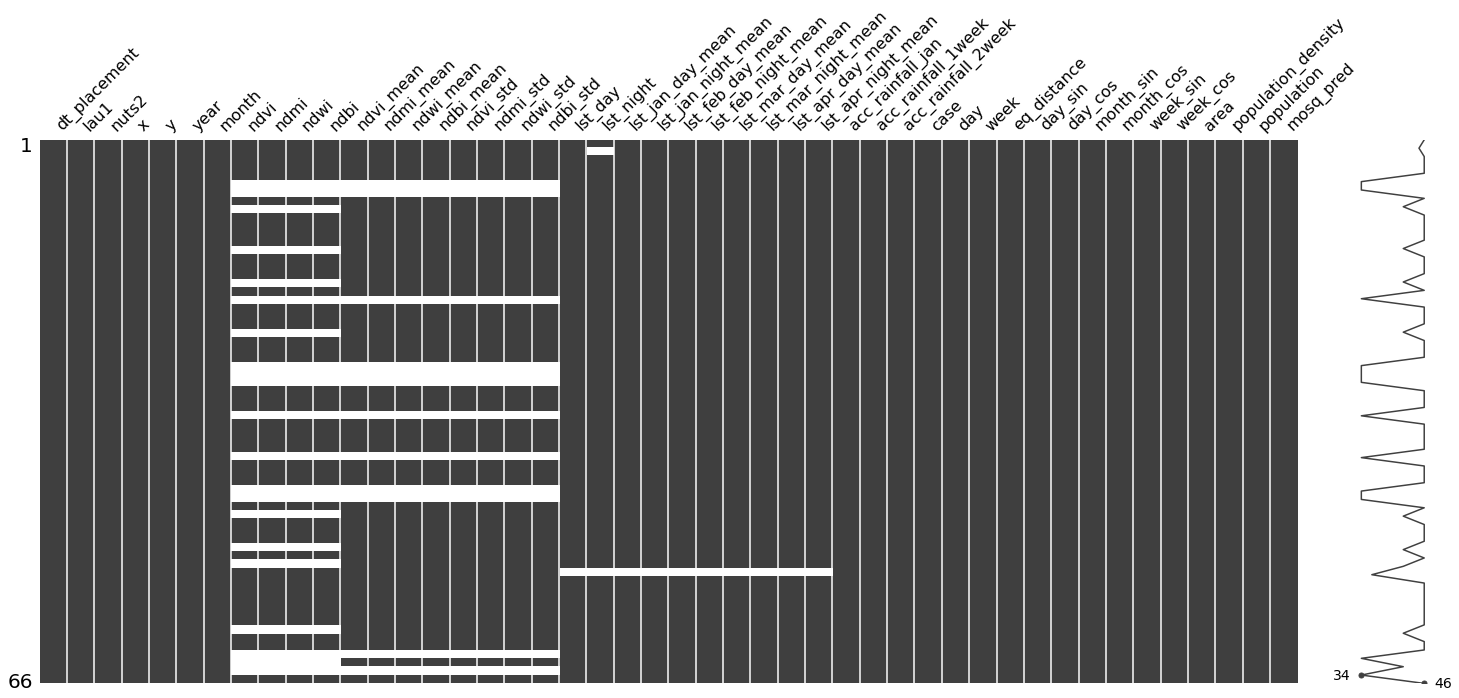

In [49]:
missingno.matrix(dataset)

In [50]:
dataset.reset_index(inplace=True, drop=True)

In [51]:
dataset = calculate_mosq_previous(dataset)

In [52]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

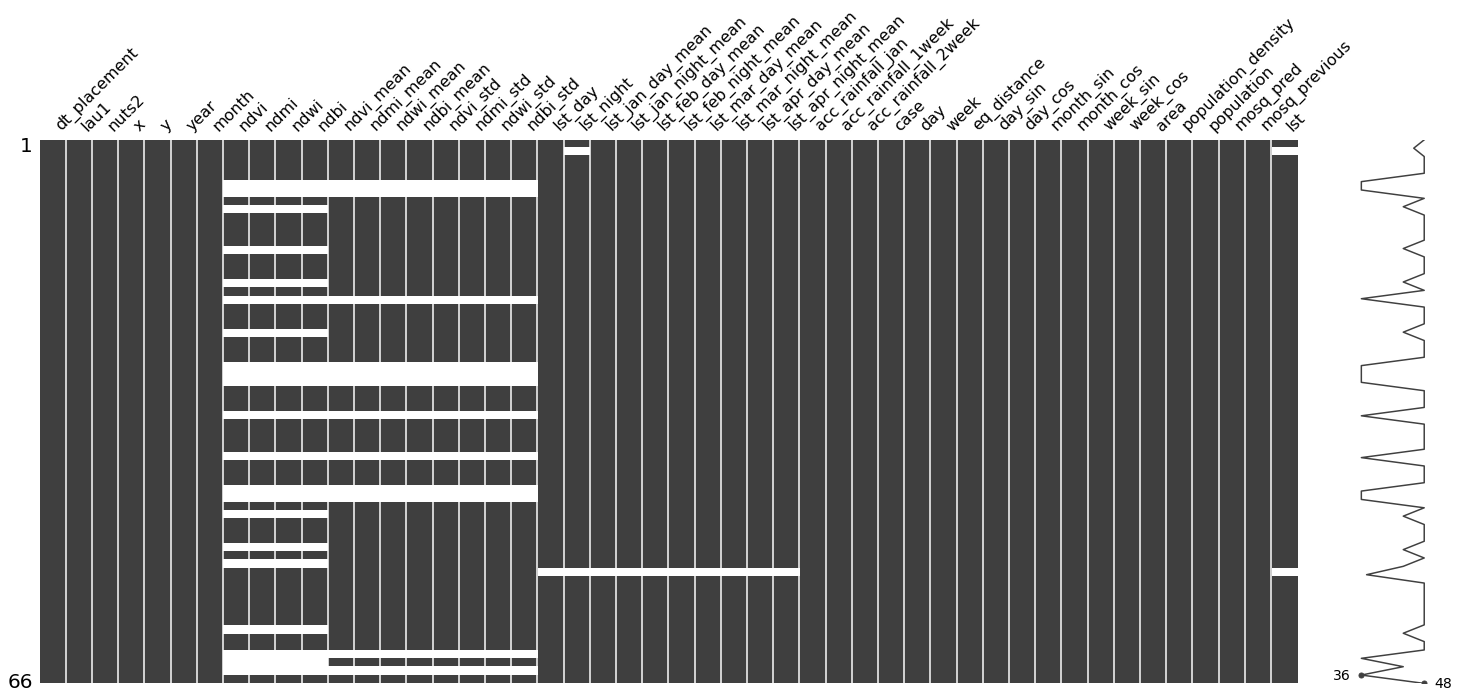

In [53]:
missingno.matrix(dataset)

In [54]:
dataset['case'].value_counts()

0    66
Name: case, dtype: int64

In [55]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [56]:
dataset = convert_multiple_cases(dataset)

In [57]:
dataset['case'].value_counts()

0    66
Name: case, dtype: int64

In [58]:
cols = dataset.columns

In [59]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'area', 'population_density',
       'population', 'mosq_pred', 'mosq_previous', 'lst'],
      dtype='object')

In [60]:
len(cols)

48

In [61]:
# check columns

In [62]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [63]:
len(final_columns)

48

In [64]:
dataset_final = dataset[final_columns].copy()

In [65]:
dataset_final

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2023-06-01,αττικης,αγιας βαρβαρας,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,2.4,26759.0,10925.9,44.75555,0.081425,-0.017010,-0.130960,0.017010,0.121710,-0.009491,-0.158340,0.009491,0.029462,0.007071,0.018681,0.007071,27.720000,35.690000,19.750000,14.510000,8.020000,13.701111,6.297619,19.888462,11.006923,23.446923,12.160000,0.0,0.0,318.222359,57,0,0
1,23.82642,38.00806,2023-06-01,αττικης,αγιας παρασκευης,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,7.9,62157.0,7557.5,44.85879,0.182029,0.039896,-0.202575,-0.039896,0.179347,0.052340,-0.193288,-0.052340,0.029700,0.018066,0.026029,0.018066,NaN,28.150000,NaN,13.528571,7.794000,15.082000,6.037273,18.770000,9.570000,21.901111,11.314000,0.0,0.0,389.356250,46,0,0
2,23.73031,37.93357,2023-06-01,αττικης,αγιου δημητριου,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,5.0,71747.0,14402.8,44.74465,0.129539,-0.004290,-0.181516,0.004290,0.109737,-0.010156,-0.161746,0.010156,0.019872,0.008452,0.017236,0.008452,27.150000,34.570000,19.730000,14.659231,9.341000,13.997273,6.772609,20.618000,10.591250,24.562941,12.900000,0.0,0.0,355.883585,51,0,0
3,23.71341,38.04721,2023-06-01,αττικης,αγιων αναργυρων καματερου,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,9.2,61427.0,6833.8,44.83209,0.138934,-0.021343,-0.182142,0.021343,0.160739,-0.030744,-0.199161,0.030744,0.028147,0.011592,0.019271,0.011592,27.150000,35.310000,18.990000,14.245000,7.601579,13.116000,6.119474,20.710000,9.976667,23.675000,11.323333,0.0,0.0,397.347602,51,0,0
4,23.34009,37.69503,2023-06-01,αττικης,αγκιστριου,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,13.4,1107.0,85.2,44.33593,0.322945,-0.016507,-0.251751,0.016507,0.312206,0.021206,-0.233773,-0.021206,0.070354,0.053917,0.070853,0.053917,20.990000,22.610000,19.370000,14.222174,10.644444,12.956316,9.337778,15.516364,11.618000,17.763600,12.083333,0.0,0.0,472.697967,42,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,23.77628,38.01477,2023-06-01,αττικης,φιλοθεης ψυχικου,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,6.1,27400.0,4421.0,44.83787,0.181323,0.085061,-0.170092,-0.085061,0.087042,0.072896,-0.070668,-0.072896,0.009643,0.014180,0.005796,0.014180,25.110000,31.410000,18.810000,13.582632,8.011053,13.871667,6.102174,18.886923,9.584444,23.132667,11.928571,0.0,0.0,397.347602,50,0,0
62,23.68862,38.10670,2023-06-01,αττικης,φυλης,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,109.1,48255.0,421.2,44.86949,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.826667,30.196667,15.456667,12.587124,5.249197,12.091667,4.206046,16.850254,7.007571,20.796111,8.497071,0.0,0.0,365.355446,71,0,0
63,23.80941,38.02226,2023-06-01,αττικης,χαλανδριου,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,10.8,77118.0,6869.6,44.86179,NaN,NaN,NaN,NaN,0.184956,0.046558,-0.206145,-0.046558,0.009028,0.006444,0.010324,0.006444,24.790000,32.410000,17.170000,13.810000,8.001579,14.400000,6.572857,19.803333,9.421765,22.716667,10.272857,0.0,0.0,389.356250,41,0,0
64,23.63084,38.00942,2023-06-01,αττικης,χαϊδαριου,1,6,22,2023,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,22.7,46983.0,2069.6,44.75637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.260000,34.770000,19.750000,13.957619,7.282222,14.100667,5.3

In [66]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-June-1st.csv", encoding = enc, index = False)